Training window: 2023-01-01 → 2026-01-31  (1127 days)
Test window:     2025-08-01  → 2025-12-31   (153 days)

=== Test metrics (Daily, Jan–Aug 2025) ===
MAE   : 729,826.51
RMSE  : 1,366,346.08
MAPE% : 8.18


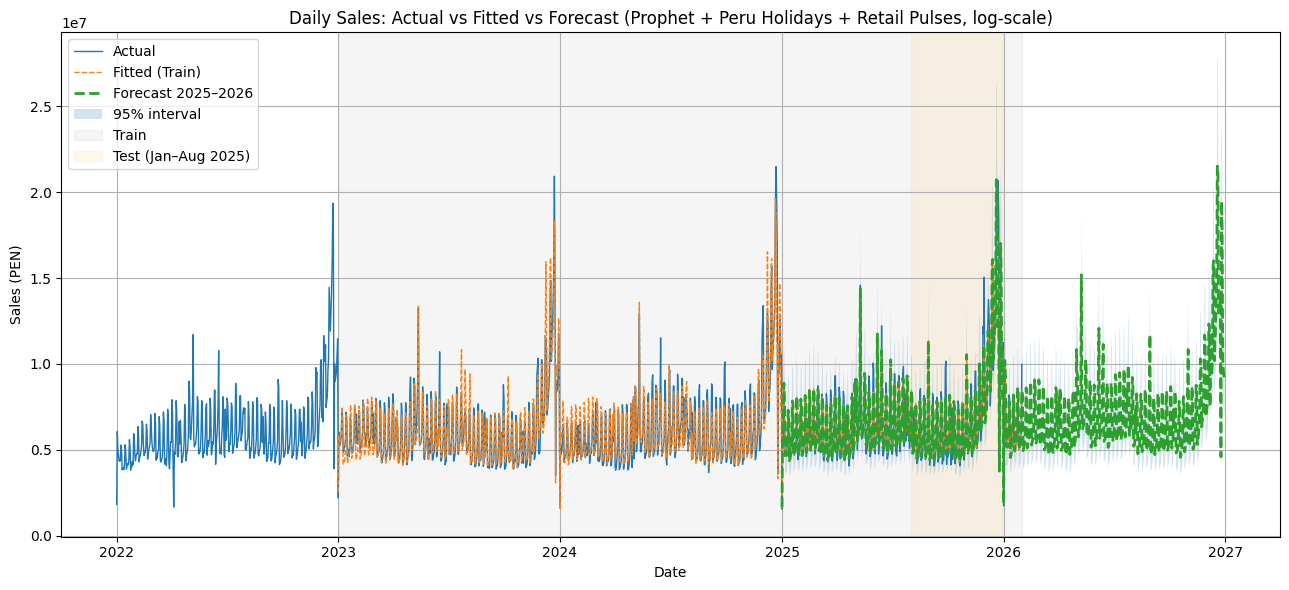

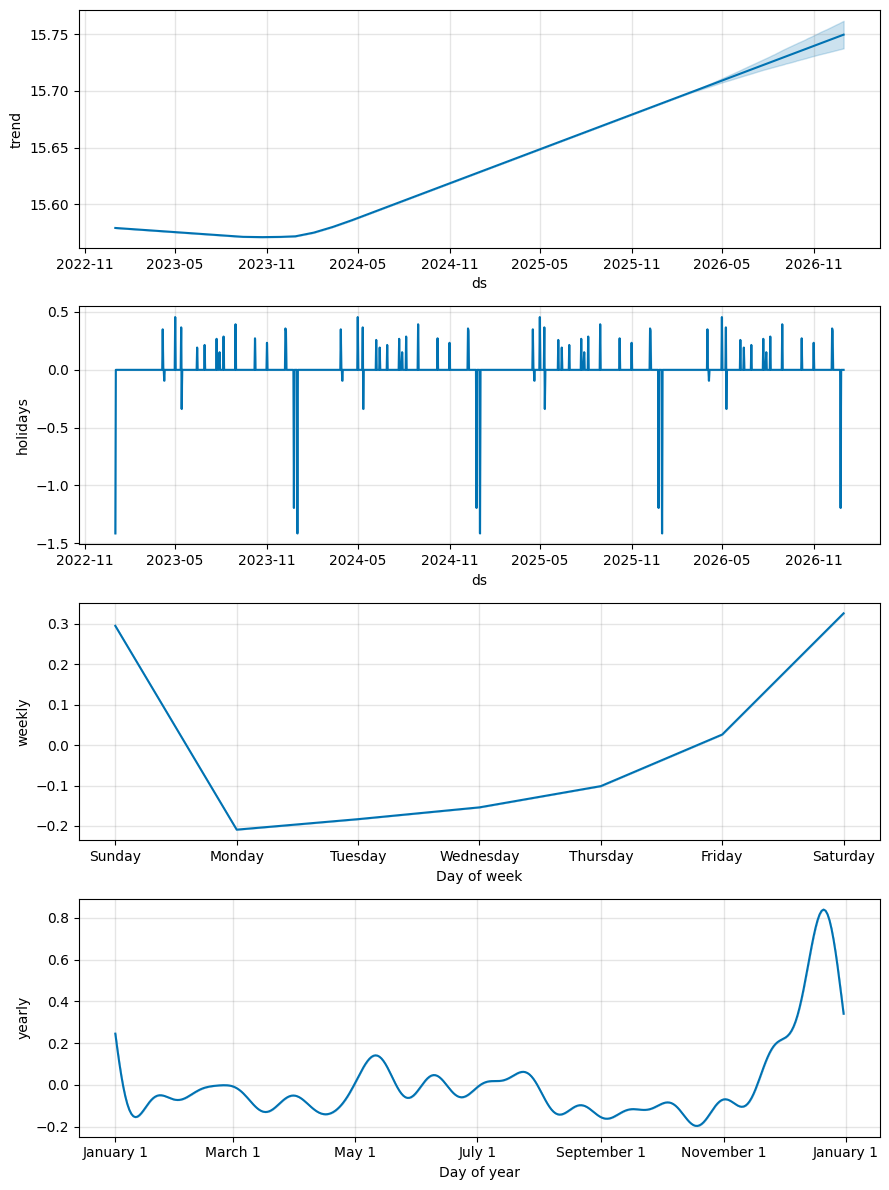

Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.
Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.

Top 25 days by absolute error:
             ds            y          yhat       abs_err       ape
356 2025-12-23  20667931.60  1.224908e+07  8.418853e+06  0.407339
357 2025-12-24  18474003.70  1.224718e+07  6.226821e+06  0.337059
355 2025-12-22  17346132.52  1.214498e+07  5.201152e+06  0.299845
360 2025-12-27  12464013.28  1.701369e+07  4.549678e+06  0.365025
333 2025-11-30  15049542.42  1.080660e+07  4.242940e+06  0.281932
331 2025-11-28  12178487.12  8.158085e+06  4.020402e+06  0.330123
364 2025-12-31  11252590.34  7.847435e+06  3.405155e+06  0.302611
367 2026-01-03   7501492.52  1.019173e+07  2.690241e+06  0.358627
363 2025-12-30  10702083.68  8.234030e+06  2.468054e+06  0.230614
270 2025-09-28  10162746.66  7.749515e+06  2.413231e+06  0.237459
341 2025-12-08  12714124.30  1.051267e+07  2.201458e+06  0.173151
241 2025-08-30   924497

In [ ]:
# @title Modelo Ventas AJP (Daily, log-scale, boosted peaks) — clean fit
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from prophet import Prophet
from datetime import date, timedelta

# Ensure Prophet uses Pystan backend
os.environ['PROPHET_BACKEND'] = 'PYSTAN'

# ---------------------------------------------------
# 1) Load & aggregate DAILY (sum per calendar day)
# ---------------------------------------------------
# If your file has an extension, include it (e.g., "...xlsx")
df_raw = pd.read_excel("Reporte_Detalle_de_Ventas_x_Local.xlsx", usecols="D,H")
df_raw.columns = ["Fecha", "Monto Soles"]

df_raw["Fecha"] = pd.to_datetime(df_raw["Fecha"]).dt.floor("D")
df_raw["Monto Soles"] = pd.to_numeric(df_raw["Monto Soles"], errors="coerce").fillna(0.0)

df_daily = (
    df_raw.groupby("Fecha", as_index=False)["Monto Soles"]
          .sum()
          .rename(columns={"Fecha": "ds", "Monto Soles": "y"})
          .sort_values("ds")
)

# Make series continuous (fill missing days with 0)
full_idx = pd.date_range(df_daily["ds"].min(), df_daily["ds"].max(), freq="D")
df_daily = (
    df_daily.set_index("ds")
            .reindex(full_idx)
            .rename_axis("ds")
            .fillna({"y": 0.0})
            .reset_index()
)

# Hard guard against any accidental duplicate dates
df_daily = (df_daily
            .groupby("ds", as_index=False)["y"].sum()
            .sort_values("ds")
            .reset_index(drop=True))

# ---------------------------------------------------
# 2) Windows
# ---------------------------------------------------
train_start = pd.Timestamp("2023-01-01")
train_end   = pd.Timestamp("2026-01-31")
test_start  = pd.Timestamp("2025-08-01")
test_end    = pd.Timestamp("2025-12-31")
fcst_end    = pd.Timestamp("2026-12-31")

data_min = min(train_start, df_daily["ds"].min())
data_max = max(fcst_end, df_daily["ds"].max())
df_daily = df_daily[(df_daily["ds"] >= data_min) & (df_daily["ds"] <= data_max)].copy()

train_df = df_daily[(df_daily["ds"] >= train_start) & (df_daily["ds"] <= train_end)].copy()
test_df  = df_daily[(df_daily["ds"] >= test_start)  & (df_daily["ds"] <= test_end)].copy()

print(f"Training window: {train_df['ds'].min().date()} → {train_df['ds'].max().date()}  ({len(train_df)} days)")
print(f"Test window:     {test_df['ds'].min().date()}  → {test_df['ds'].max().date()}   ({len(test_df)} days)")

# ---------------------------------------------------
# 3) Log-transform target (multiplicative effects on original scale)
# ---------------------------------------------------
df_log = df_daily.copy()
df_log["y_log"] = np.log1p(df_log["y"])  # robust with zeros

# Build CLEAN train_fit directly from df_log (avoid merges that duplicate columns)
train_fit = df_log[(df_log["ds"] >= train_start) & (df_log["ds"] <= train_end)][["ds","y_log"]] \
                 .rename(columns={"y_log":"y"}) \
                 .copy()

# Assert uniqueness of ds for Prophet; auto-fix if needed
dupes = train_fit["ds"].duplicated().sum()
if dupes:
    print(f"[WARN] Found {dupes} duplicate ds in train_fit; aggregating duplicates.")
    train_fit = train_fit.groupby("ds", as_index=False)["y"].mean()

# ---------------------------------------------------
# 4) Holidays: official Peru + custom retail pulses (taller, not wider)
# ---------------------------------------------------
years = list(range(train_start.year, fcst_end.year + 1))

# Official Peru holidays
peru_holidays = pd.DataFrame(
    [(d, n) for y in years for d, n in holidays.Peru(years=y).items()],
    columns=["ds", "holiday"]
)
peru_holidays["ds"] = pd.to_datetime(peru_holidays["ds"])

# Remove Dec 8 so effect isn't split
peru_holidays = peru_holidays[
    ~((peru_holidays["ds"].dt.month == 12) & (peru_holidays["ds"].dt.day == 8))
]

# Helpers
def nth_weekday(year, month, weekday, n):  # Mon=0..Sun=6
    d = date(year, month, 1)
    shift = (weekday - d.weekday()) % 7
    first = d + timedelta(days=shift)
    return first + timedelta(weeks=n-1)

# Custom events across all years (Mother's Day SAT/SUN, Gratificacion day)
rows = []
for y in years:
    # Mother's Day: 2nd Sunday of May (Peru) — Saturday is the biggest retail day
    md_sun = nth_weekday(y, 5, 6, 2)
    rows += [
        {"holiday":"MothersDay_Sat","ds": pd.Timestamp(md_sun) - pd.Timedelta(days=1),
         "lower_window":0,"upper_window":0,"prior_scale":65},
        {"holiday":"MothersDay_Sun","ds": pd.Timestamp(md_sun),
         "lower_window":0,"upper_window":0,"prior_scale":25},
    ]
    # Gratificacion: June 14 (single-day)
    rows.append(
        {"holiday":"Gratificacion","ds": pd.Timestamp(f"{y}-06-14"),
         "lower_window":0,"upper_window":0,"prior_scale":30}
    )

custom = pd.DataFrame(rows)

# Single tall pulse for Dec 8 (Immaculate Conception)
dec8_boost = pd.DataFrame({
    "holiday": "Dec8_Boost",
    "ds": [pd.Timestamp(f"{y}-12-08") for y in years],
    "lower_window": 0,
    "upper_window": 0,
    "prior_scale": 110  # raise if still short (e.g., 120)
})

# Final holiday table
all_holidays = (
    pd.concat([peru_holidays, custom, dec8_boost], ignore_index=True)
      .drop_duplicates(subset=["holiday","ds"])
      .sort_values(["ds","holiday"])
      .reset_index(drop=True)
)

# ---------------------------------------------------
# 5) Model (additive in log-space → multiplicative on original scale)
# ---------------------------------------------------
m = Prophet(
    holidays=all_holidays,       # per-row prior_scale overrides global
    holidays_prior_scale=28.0,
    yearly_seasonality=15,
    weekly_seasonality=6,
    daily_seasonality=False,
    seasonality_prior_scale=14.0,
    changepoint_prior_scale=0.001,  # tight trend (stable)
    changepoint_range=0.8,
    n_changepoints=25,
    interval_width=0.95,
    seasonality_mode="additive"
)
"""
# Intra-month cycle on daily data
m.add_seasonality(name="monthly", period=30.5, fourier_order=9)
"""
# Fit on LOG target
m.fit(train_fit)

# ---------------------------------------------------
# 6) Forecast through 2026-12-31 and back-transform
# ---------------------------------------------------
periods_needed = (fcst_end - train_end).days
future = m.make_future_dataframe(periods=periods_needed, freq="D", include_history=True)
forecast = m.predict(future)

# Back-transform to original units
forecast["yhat"]       = np.expm1(forecast["yhat"])
forecast["yhat_lower"] = np.expm1(forecast["yhat_lower"])
forecast["yhat_upper"] = np.expm1(forecast["yhat_upper"])

# ---------------------------------------------------
# 7) Evaluation (Test: 2025-01-01 → 2025-08-31)
# ---------------------------------------------------
pred_test = forecast[(forecast["ds"] >= test_start) & (forecast["ds"] <= test_end)][
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].merge(test_df, on="ds", how="inner")

def mae(a, b):  return float(np.mean(np.abs(a - b)))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def mape_pct(a, b, eps=1e-8):
    mask = np.abs(a) > eps
    return float(np.mean(np.abs((a[mask]-b[mask]) / a[mask]))*100) if mask.sum() else np.nan

test_mae  = mae(pred_test["y"].values,   pred_test["yhat"].values)
test_rmse = rmse(pred_test["y"].values,  pred_test["yhat"].values)
test_mape = mape_pct(pred_test["y"].values, pred_test["yhat"].values)

print("\n=== Test metrics (Daily, Jan–Aug 2025) ===")
print(f"MAE   : {test_mae:,.2f}")
print(f"RMSE  : {test_rmse:,.2f}")
print(f"MAPE% : {test_mape:,.2f}")

# ---------------------------------------------------
# 8) Plots
# ---------------------------------------------------
plt.figure(figsize=(13,6))
plt.plot(df_daily["ds"], df_daily["y"], label="Actual", linewidth=1)

# In-sample fitted (back-transformed)
fitted_hist = forecast[(forecast["ds"] >= train_start) & (forecast["ds"] <= train_end)]
plt.plot(fitted_hist["ds"], fitted_hist["yhat"], label="Fitted (Train)", linestyle="--", linewidth=1)

# Forecast 2025–2026
fcst_horiz = forecast[(forecast["ds"] >= pd.Timestamp("2025-01-01")) & (forecast["ds"] <= fcst_end)]
plt.plot(fcst_horiz["ds"], fcst_horiz["yhat"], label="Forecast 2025–2026", linestyle="--", linewidth=2)
plt.fill_between(fcst_horiz["ds"], fcst_horiz["yhat_upper"], fcst_horiz["yhat_lower"], alpha=0.2, label="95% interval")

# Shade train/test
plt.axvspan(train_start, train_end, color="grey", alpha=0.08, label="Train")
plt.axvspan(test_start,  test_end,  color="orange", alpha=0.08, label="Test (Jan–Aug 2025)")

plt.title("Daily Sales: Actual vs Fitted vs Forecast (Prophet + Peru Holidays + Retail Pulses, log-scale)")
plt.xlabel("Date"); plt.ylabel("Sales (PEN)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Components
m.plot_components(forecast); plt.tight_layout(); plt.show()

# ---------------------------------------------------
# 9) Exports
# ---------------------------------------------------
out = fcst_horiz.copy()
out["deseasonalized"] = out["trend"]  # trend was modeled in log-space
out_cols = ["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "deseasonalized"]
out[out_cols].to_excel("prophet_forecast_2025_2026_daily.xlsx", index=False)
print("Exported daily forecast to 'prophet_forecast_2025_2026_daily.xlsx'.")

monthly_2526 = (
    out.set_index("ds")[["yhat","yhat_lower","yhat_upper","trend"]]
      .resample("MS").sum(min_count=1)
      .reset_index()
)
monthly_2526.to_excel("prophet_forecast_2025_2026_monthly_from_daily.xlsx", index=False)
print("Exported monthly summaries to 'prophet_forecast_2025_2026_monthly_from_daily.xlsx'.")

# ---------------------------------------------------
# 10) Peak diagnostics (optional)
# ---------------------------------------------------
mask = (forecast["ds"] >= "2025-01-01") & (forecast["ds"] <= "2026-12-31")
pred = forecast.loc[mask, ["ds","yhat","yhat_lower","yhat_upper"]].merge(df_daily[["ds","y"]], on="ds", how="left")
pred["err"] = pred["y"] - pred["yhat"]
pred["abs_err"] = pred["err"].abs()
pred["squared_err"] = pred["err"]**2
pred["ape"] = pred["abs_err"] / np.where(pred["y"].abs()>1e-8, pred["y"], np.nan)

top_abs = pred.nlargest(25, "abs_err")[["ds","y","yhat","abs_err","ape"]]
print("\nTop 25 days by absolute error:\n", top_abs)

# Map events
ev_map = (all_holidays.groupby("ds")["holiday"]
                 .apply(lambda s: ",".join(sorted(set(s))))
                 .reset_index()
                 .rename(columns={"holiday":"event"}))
top_with_events = top_abs.merge(ev_map, on="ds", how="left")
print("\nTop 25 with event labels:\n", top_with_events[["ds","event","y","yhat","abs_err","ape"]])

# Check Dec 8 heights by year
for yr in [2022, 2023, 2024, 2025, 2026]:
    row = forecast.loc[forecast["ds"] == pd.Timestamp(f"{yr}-12-08"), ["ds","yhat","holidays","trend"]]
    print(row.to_string(index=False))
